# Notebook 2 — Data Collection & Understanding
## Dataset: NSL-KDD Network Intrusion Detection

In [9]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_dataset, dataset_summary, COLUMN_NAMES

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

In [2]:
# Download (if needed) and load
train_df, test_df = load_dataset(data_dir='../data/raw', auto_download=True)

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
train_df.head(3)

Train: (125973, 45)  |  Test: (22544, 45)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level,binary_label,attack_category
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.0,150,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20,0,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.0,255,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15,0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.0,255,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19,1,dos


## Dataset Overview

In [3]:
summary = dataset_summary(train_df)
print('Shape:         ', summary['shape'])
print('Missing values:', summary['missing_values'])
print('Duplicates:    ', summary['duplicate_rows'])
print('Label distribution (train):')
for k, v in summary['label_distribution'].items():
    print(f'  {k}: {v:.1%}')

Shape:          (125973, 45)
Missing values: 0
Duplicates:     0
Label distribution (train):
  0: 53.5%
  1: 46.5%


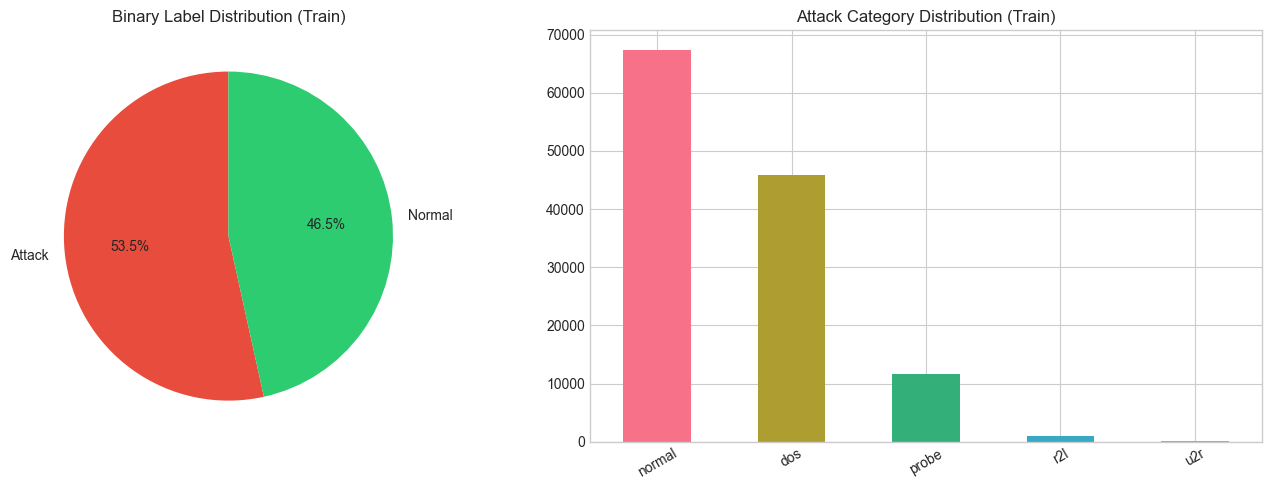

In [4]:
# Attack category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
binary_counts = train_df['binary_label'].value_counts()
axes[0].pie(binary_counts, labels=['Attack', 'Normal'], autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[0].set_title('Binary Label Distribution (Train)')

# Multi-class
cat_counts = train_df['attack_category'].value_counts()
cat_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('husl', len(cat_counts)))
axes[1].set_title('Attack Category Distribution (Train)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/label_distribution.png', dpi=150)
plt.show()

In [5]:
# Feature type summary
type_summary = train_df.dtypes.value_counts()
print('Data types:')
print(type_summary)

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
print(f'\nNumeric features:     {len(numeric_cols)}')
print(f'Categorical features: {len(categorical_cols)}')
print(f'Categorical values:   {categorical_cols}')

Data types:
int64      25
float64    15
object      5
Name: count, dtype: int64

Numeric features:     40
Categorical features: 5
Categorical values:   ['protocol_type', 'service', 'flag', 'label', 'attack_category']


In [6]:
# Descriptive statistics for key numeric features
key_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
                'serror_rate', 'rerror_rate', 'same_srv_rate', 'dst_host_count']
train_df[key_features].describe().round(2)

,duration,src_bytes,dst_bytes,count,srv_count,serror_rate,rerror_rate,same_srv_rate,dst_host_count
count,125973.00,1.259730e+05,1.259730e+05,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00
mean,287.14,4.556674e+04,1.977911e+04,84.11,27.74,0.28,0.12,0.66,182.15
std,2604.52,5.870331e+06,4.021269e+06,114.51,72.64,0.45,0.32,0.44,99.21
min,0.00,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.000000e+00,0.000000e+00,2.00,2.00,0.00,0.00,0.09,82.00
50%,0.00,4.400000e+01,0.000000e+00,14.00,8.00,0.00,0.00,1.00,255.00
75%,0.00,2.760000e+02,5.160000e+02,143.00,18.00,1.00,0.00,1.00,255.00
max,42908.00,1.379964e+09,1.309937e+09,511.00,511.00,1.00,1.00,1.00,255.00


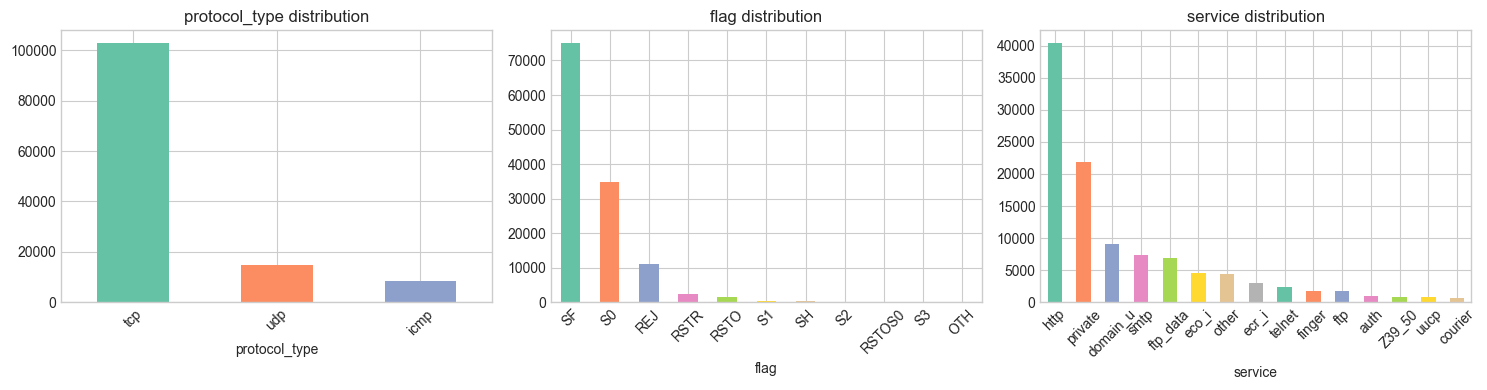

In [7]:
# Protocol type distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['protocol_type', 'flag', 'service']):
    vc = train_df[col].value_counts().head(15)
    vc.plot(kind='bar', ax=axes[i], color=sns.color_palette('Set2', len(vc)))
    axes[i].set_title(f'{col} distribution')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../reports/categorical_distributions.png', dpi=150)
plt.show()

## Data Dictionary

| # | Feature | Type | Description | Range / Values |
|---|---------|------|-------------|----------------|
| 1 | duration | numeric | Length of connection (seconds) | 0–58329 |
| 2 | protocol_type | categorical | Network protocol | tcp, udp, icmp |
| 3 | service | categorical | Destination service | http, ftp, smtp, … (70 values) |
| 4 | flag | categorical | Connection status | SF, S0, REJ, RSTO, … (11 values) |
| 5 | src_bytes | numeric | Data bytes from source to destination | 0–1.38B |
| 6 | dst_bytes | numeric | Data bytes from destination to source | 0–1.31B |
| 7 | land | binary | 1 if source/destination same host/port | 0, 1 |
| 8 | wrong_fragment | numeric | # of 'wrong' fragments | 0–3 |
| 9 | urgent | numeric | # of urgent packets | 0–14 |
| 10 | hot | numeric | # of hot indicators | 0–101 |
| 11 | num_failed_logins | numeric | # of failed login attempts | 0–5 |
| 12 | logged_in | binary | 1 if successfully logged in | 0, 1 |
| 13 | num_compromised | numeric | # of compromised conditions | 0–7479 |
| 14 | root_shell | binary | 1 if root shell obtained | 0, 1 |
| 15 | su_attempted | binary | 1 if su root command attempted | 0, 1 |
| 16–20 | num_root, num_file_creations, num_shells, num_access_files, num_outbound_cmds | numeric | Operation counts | ≥0 |
| 21 | is_host_login | binary | 1 if login belongs to host list | 0, 1 |
| 22 | is_guest_login | binary | 1 if login is 'guest' | 0, 1 |
| 23 | count | numeric | Connections to same host in last 2s | 0–511 |
| 24 | srv_count | numeric | Connections to same service in last 2s | 0–511 |
| 25–30 | serror_rate, srv_serror_rate, rerror_rate, srv_rerror_rate, same_srv_rate, diff_srv_rate | numeric | Rate-based statistical features | 0.0–1.0 |
| 31 | srv_diff_host_rate | numeric | % connections to different hosts | 0.0–1.0 |
| 32–41 | dst_host_* | numeric | Destination host-level aggregated stats | 0–511 or 0.0–1.0 |
| 42 | label | categorical (target) | Attack type or 'normal' | normal, neptune, smurf, … |
| 43 | binary_label | binary (derived) | 0=normal, 1=attack | 0, 1 |

In [8]:
# Save full data dictionary to CSV
data_dict = pd.DataFrame({
    'feature': COLUMN_NAMES[:-1],  # exclude difficulty_level
    'dtype': [str(train_df[c].dtype) if c in train_df.columns else 'N/A'
              for c in COLUMN_NAMES[:-1]],
    'n_unique': [train_df[c].nunique() if c in train_df.columns else -1
                 for c in COLUMN_NAMES[:-1]],
    'missing_pct': [train_df[c].isnull().mean() * 100 if c in train_df.columns else -1
                    for c in COLUMN_NAMES[:-1]],
    'example_values': [str(train_df[c].unique()[:3].tolist()) if c in train_df.columns else ''
                       for c in COLUMN_NAMES[:-1]],
})

data_dict.to_csv('../reports/data_dictionary.csv', index=False)
print('Data dictionary saved.')
data_dict.head(10)

Data dictionary saved.


,feature,dtype,n_unique,missing_pct,example_values
0,duration,int64,2981,0.0,"[0, 5607, 507]"
1,protocol_type,object,3,0.0,"['tcp', 'udp', 'icmp']"
2,service,object,70,0.0,"['ftp_data', 'other', 'private']"
3,flag,object,11,0.0,"['SF', 'S0', 'REJ']"
4,src_bytes,int64,3341,0.0,"[491, 146, 0]"
5,dst_bytes,int64,9326,0.0,"[0, 8153, 420]"
6,land,int64,2,0.0,"[0, 1]"
7,wrong_fragment,int64,3,0.0,"[0, 3, 1]"
8,urgent,int64,4,0.0,"[0, 1, 3]"
9,hot,int64,28,0.0,"[0, 5, 6]"


---
## 2.9 Outlier Analysis
Box plots and IQR-based outlier counts for the most security-relevant numeric features.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

outlier_features = ['src_bytes', 'dst_bytes', 'duration', 'count',
                    'num_compromised', 'serror_rate', 'same_srv_rate']

fig, axes = plt.subplots(1, len(outlier_features), figsize=(16, 4))
for ax, col in zip(axes, outlier_features):
    ax.boxplot(train_df[col].clip(upper=train_df[col].quantile(0.995)),
               showfliers=True, flierprops=dict(marker='.', markersize=1, alpha=0.3))
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])

fig.suptitle('Outlier Distribution (clipped at 99.5th percentile for visibility)', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/outlier_boxplots.png', dpi=150)
plt.show()

# IQR-based outlier count per feature
print(f"{'Feature':<30}  {'Outliers (3×IQR)':>18}  {'% of rows':>10}")
print('-' * 62)
numeric_only = train_df.select_dtypes(include=[np.number]).columns
for col in numeric_only:
    q1, q3 = train_df[col].quantile(0.25), train_df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((train_df[col] < q1 - 3*iqr) | (train_df[col] > q3 + 3*iqr)).sum()
    if n_out > 0:
        print(f"{col:<30}  {n_out:>18,}  {n_out/len(train_df):>9.1%}")

---
## 2.10 Train vs. Test Distribution Comparison
NSL-KDD's test set (KDDTest+) is intentionally harder — it contains attack subtypes **not seen in training**. Understanding this split is critical to interpreting model performance.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Binary label comparison
print("=== Binary Label Distribution ===")
print(f"{'Split':<8}  {'Normal':>8}  {'Attack':>8}  {'Attack%':>8}")
for name, df in [('Train', train_df), ('Test', test_df)]:
    n = (df['binary_label'] == 0).sum()
    a = (df['binary_label'] == 1).sum()
    print(f"{name:<8}  {n:>8,}  {a:>8,}  {a/(n+a):>7.1%}")

# Attack category comparison
print("\n=== Attack Category Distribution ===")
train_cat = train_df['attack_category'].value_counts(normalize=True).rename('train_%')
test_cat  = test_df['attack_category'].value_counts(normalize=True).rename('test_%')
cat_compare = pd.concat([train_cat, test_cat], axis=1).fillna(0).round(3)
print(cat_compare.to_string())

# Unique attack subtypes in test not seen in training
train_attacks = set(train_df[train_df['binary_label']==1]['label'].unique())
test_attacks  = set(test_df[test_df['binary_label']==1]['label'].unique())
novel = test_attacks - train_attacks
print(f"\nNovel attack subtypes in KDDTest+ (not in training): {len(novel)}")
print(sorted(novel))

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cat_compare.drop('normal', errors='ignore').plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Attack Category: Train vs Test (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Proportion')

# Key feature distributions: train vs test (serror_rate)
for label, df, color in [('Train', train_df, 'steelblue'), ('Test', test_df, 'tomato')]:
    axes[1].hist(df['serror_rate'], bins=30, alpha=0.5, label=label, color=color, density=True)
axes[1].set_title('serror_rate distribution: Train vs Test')
axes[1].set_xlabel('serror_rate'); axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/train_test_comparison.png', dpi=150)
plt.show()

print("\nKey insight: KDDTest+ has a higher proportion of novel/rare attack types")
print("(U2R, R2L variants) not present in training — this explains the train-test")
print("generalisation gap observed in Notebook 04 results.")

---
## 2.11 Enhanced Data Dictionary (with Units)
Extended with units and security meaning columns to meet the rubric's "variables, types, ranges/units" requirement.

In [ ]:
import pandas as pd

enhanced_dict = pd.DataFrame([
    # (feature, type, unit, range, security_meaning)
    ('duration',              'numeric',     'seconds',       '0–58329',        'Connection length — long durations may indicate tunnelling'),
    ('protocol_type',         'categorical', 'N/A',           'tcp/udp/icmp',   'Network protocol — ICMP often used in ping floods'),
    ('service',               'categorical', 'N/A',           '70 values',      'Destination service — unusual services flag recon/exploits'),
    ('flag',                  'categorical', 'N/A',           '11 values',      'TCP status — S0 (no reply) and REJ are strong attack signals'),
    ('src_bytes',             'numeric',     'bytes',         '0–1.38B',        'Data sent — zero bytes typical in SYN floods'),
    ('dst_bytes',             'numeric',     'bytes',         '0–1.31B',        'Data received — extreme values indicate exfiltration'),
    ('land',                  'binary',      'flag (0/1)',    '0,1',            'Source = destination — spoof attack indicator'),
    ('wrong_fragment',        'numeric',     'count',         '0–3',            'Malformed packets — may indicate evasion'),
    ('urgent',                'numeric',     'count',         '0–14',           'Urgent packets — rarely legitimate'),
    ('hot',                   'numeric',     'count',         '0–101',          'Hot indicators — privilege abuse counter'),
    ('num_failed_logins',     'numeric',     'count',         '0–5',            'Failed logins — brute-force indicator'),
    ('logged_in',             'binary',      'flag (0/1)',    '0,1',            'Authenticated session — normal traffic predictor'),
    ('num_compromised',       'numeric',     'count',         '0–7479',         'Compromised conditions — R2L/U2R severity'),
    ('root_shell',            'binary',      'flag (0/1)',    '0,1',            'Root shell obtained — U2R critical indicator'),
    ('su_attempted',          'binary',      'flag (0/1)',    '0,1',            'su root attempted — privilege escalation'),
    ('count',                 'numeric',     'connections/2s','0–511',          'Same-host connections — scan/flood detector'),
    ('srv_count',             'numeric',     'connections/2s','0–511',          'Same-service connections — service scan indicator'),
    ('serror_rate',           'numeric',     'ratio (0–1)',   '0.0–1.0',        'SYN error rate — primary SYN flood / DoS indicator'),
    ('rerror_rate',           'numeric',     'ratio (0–1)',   '0.0–1.0',        'REJ error rate — firewall-blocked connection indicator'),
    ('same_srv_rate',         'numeric',     'ratio (0–1)',   '0.0–1.0',        'Same-service ratio — low = port scan'),
    ('diff_srv_rate',         'numeric',     'ratio (0–1)',   '0.0–1.0',        'Different-service ratio — high = service scan'),
    ('srv_diff_host_rate',    'numeric',     'ratio (0–1)',   '0.0–1.0',        'Different-host ratio — horizontal scan'),
    ('dst_host_count',        'numeric',     'connections',   '0–255',          'Host connection count — host-level scan density'),
    ('dst_host_srv_count',    'numeric',     'connections',   '0–255',          'Host-service count — targeted service scan'),
    ('dst_host_same_srv_rate','numeric',     'ratio (0–1)',   '0.0–1.0',        'Host same-service rate — service concentration'),
    ('dst_host_serror_rate',  'numeric',     'ratio (0–1)',   '0.0–1.0',        'Host SYN error accumulation — persistent DoS'),
    ('dst_host_rerror_rate',  'numeric',     'ratio (0–1)',   '0.0–1.0',        'Host REJ error rate — blocked connection history'),
    ('label',                 'categorical', 'N/A',           'normal/neptune/…','Original 39-class attack label (KDDTrain+)'),
    ('binary_label',          'binary',      'flag (0/1)',    '0=normal,1=attack','Derived target variable for binary classification'),
], columns=['feature', 'type', 'unit', 'range', 'security_meaning'])

enhanced_dict.to_csv('../reports/data_dictionary.csv', index=False)
print(f"Enhanced data dictionary saved ({len(enhanced_dict)} features).")
enhanced_dict